In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    "../data/processed/judo_techniques.csv"
)

valid_groups = [24,25,29,31,33,35]

technique_df = df[
    df["tag_group"].isin(valid_groups)
].copy()

remove_tags = [
    "Right",
    "Left",
    "Cancel Waza-ari",
    "Cancel Yuko",
    "No score"
]

technique_df = technique_df[
    ~technique_df["technique"].isin(remove_tags)
]

technique_df.head()

,competition,date,weight,contest_code,winner,white,blue,country_white,country_blue,time_seconds,technique,score_type,tag_group
3,Qingdao Grand Prix 2026,2026-06-26,-63,gp_chn2026_0002_f_0063_0001,OBERAN Iva,OBERAN Iva,PRIMO Kerem,Croatia,Israel,234.52,Ura-nage,Yuko,31
5,Qingdao Grand Prix 2026,2026-06-26,-63,gp_chn2026_0002_f_0063_0001,OBERAN Iva,OBERAN Iva,PRIMO Kerem,Croatia,Israel,340.01,Sumi-gaeshi,Ippon,31
6,Qingdao Grand Prix 2026,2026-06-26,-48,gp_chn2026_0002_f_0048_0002,LEE Yoojin,GANBAATAR Byambasuren,LEE Yoojin,Mongolia,Republic of Korea,407.77,Ko-uchi-makikomi,Yuko,35
7,Qingdao Grand Prix 2026,2026-06-26,-63,gp_chn2026_0002_f_0063_0002,DEBERDT Gaetane,DEBERDT Gaetane,SANCHEZ BENITEZ Ariela,France,Spain,187.97,Tani-otoshi,Yuko,35
9,Qingdao Grand Prix 2026,2026-06-26,-63,gp_chn2026_0002_f_0063_0002,DEBERDT Gaetane,DEBERDT Gaetane,SANCHEZ BENITEZ Ariela,France,Spain,247.04,Yoko-guruma,Yuko,35


# Top Techniques Used - What techniques appear most often in international competition?

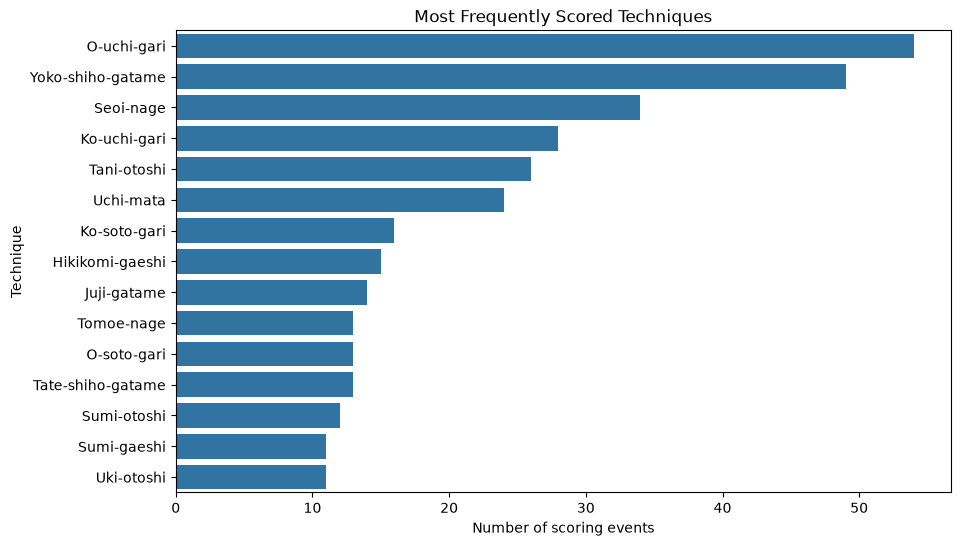

In [38]:
top = (
    technique_df["technique"]
    .value_counts()
    .head(15)
)

plt.figure(figsize=(10,6))

sns.barplot(
    x=top.values,
    y=top.index
)

plt.title(
    "Most Frequently Scored Techniques"
)

plt.xlabel("Number of scoring events")
plt.ylabel("Technique")

plt.show()




Ippon conversion rate - Which techniques actually finish fights?

In [25]:
technique_df["is_ippon"] = (
    technique_df["score_type"]
    .isin([
        "Ippon",
        "Waza-ari-awasete-ippon"
    ])
)

In [ ]:
ippon_rate = (
    technique_df
    .groupby("technique")
    .agg(
        attempts=("technique","count"),
        ippon_rate=("is_ippon","mean")
    )
    .query("attempts >= 5")
    .sort_values(
        "ippon_rate",
        ascending=False
    )
)

ippon_rate_label = ippon_rate[
    ippon_rate["attempts"] >= 5
]

ippon_rate.head(15)

,attempts,ippon_rate
technique,,
Juji-gatame,14,1.000000
Kuzure-kesa-gatame,10,1.000000
Kuzure-kami-shiho-gatame,11,0.727273
Yoko-shiho-gatame,49,0.632653
Tate-shiho-gatame,13,0.615385
Soto-makikomi,5,0.600000
Seoi-otoshi,7,0.428571
Seoi-nage,34,0.294118
Ippon-seoi-nage,7,0.285714


Technique effectiveness 

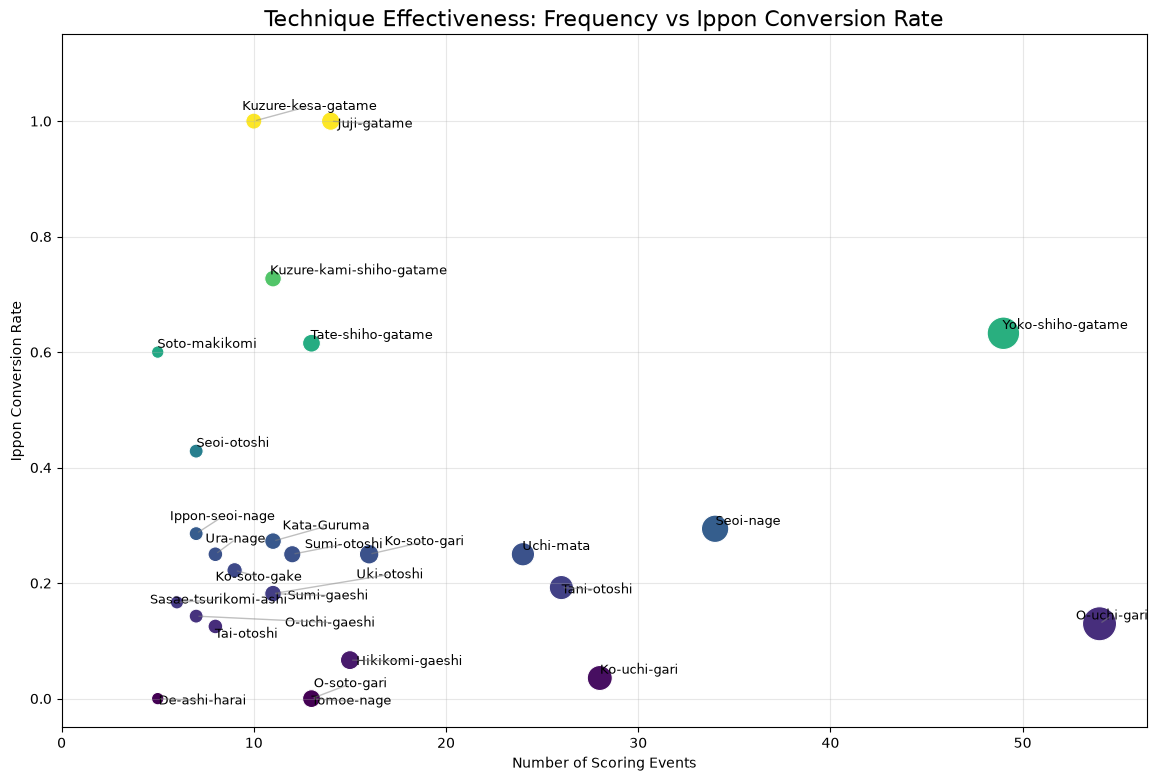

In [35]:
from adjustText import adjust_text

plt.figure(figsize=(14, 9))

ax = sns.scatterplot(
    data=ippon_rate_label,
    x="attempts",
    y="ippon_rate",
    size="attempts",
    hue="ippon_rate",
    palette="viridis",
    sizes=(80, 600),
    legend=False
)

texts = []

for technique, row in ippon_rate_label.iterrows():
    texts.append(
        ax.text(
            row["attempts"],
            row["ippon_rate"],
            technique,
            fontsize=9
        )
    )

adjust_text(
    texts,
    x=ippon_rate_label["attempts"],
    y=ippon_rate_label["ippon_rate"],
    arrowprops=dict(
        arrowstyle="-",
        color="gray",
        alpha=0.5
    ),
    expand_points=(2, 2),
    expand_text=(2, 2),
    force_text=(0.5, 0.8)
)

# Add padding so labels at 1.0 are visible
plt.ylim(
    -0.05,
    1.15
)

plt.xlim(
    left=0
)

plt.title(
    "Technique Effectiveness: Frequency vs Ippon Conversion Rate",
    fontsize=16
)

plt.xlabel(
    "Number of Scoring Events"
)

plt.ylabel(
    "Ippon Conversion Rate"
)

plt.grid(
    alpha=0.3
)

plt.show()

# Most effective techniques

In [36]:
technique_ranking = (
    technique_df
    .groupby("technique")
    .agg(
        attempts=("technique", "count"),
        ippons=("is_ippon", "sum"),
        ippon_rate=("is_ippon", "mean")
    )
    .query("attempts >= 5")
    .sort_values(
        "ippon_rate",
        ascending=False
    )
)

technique_ranking.head(15)

,attempts,ippons,ippon_rate
technique,,,
Juji-gatame,14,14,1.000000
Kuzure-kesa-gatame,10,10,1.000000
Kuzure-kami-shiho-gatame,11,8,0.727273
Yoko-shiho-gatame,49,31,0.632653
Tate-shiho-gatame,13,8,0.615385
Soto-makikomi,5,3,0.600000
Seoi-otoshi,7,3,0.428571
Seoi-nage,34,10,0.294118
Ippon-seoi-nage,7,2,0.285714


# Weight class differences

In [39]:
weight_analysis = (
    technique_df
    .groupby(
        ["weight", "technique"]
    )
    .size()
    .reset_index(
        name="count"
    )
)

weight_analysis.sort_values(
    "count",
    ascending=False
).head(20)

,weight,technique,count
195,-48,O-uchi-gari,9
239,100,Yoko-shiho-gatame,8
54,-81,Seoi-nage,7
146,-63,Yoko-shiho-gatame,7
136,-63,O-uchi-gari,6
111,-70,O-uchi-gari,6
61,-81,Uchi-mata,6
97,-73,Tomoe-nage,6
233,100,Seoi-nage,6
139,-63,Tani-otoshi,6


- Do lighter divisions favor faster throws?
- Do heavier divisions score more with groundwork?
- Are certain techniques dominant in certain classes?

"Signature techniques by Division" table

In [41]:
top_by_weight = (
    technique_df
    .groupby(["weight", "technique"])
    .size()
    .reset_index(name="count")
)

top_by_weight = (
    top_by_weight
    .sort_values(
        ["weight", "count"],
        ascending=[True, False]
    )
)

top_by_weight.groupby("weight").head(3)

,weight,technique,count
7,-100,Ko-soto-gari,4
21,-100,Tani-otoshi,4
1,-100,Hikikomi-gaeshi,3
33,-90,O-uchi-gari,3
43,-90,Yoko-shiho-gatame,3
29,-90,Kata-Guruma,2
54,-81,Seoi-nage,7
61,-81,Uchi-mata,6
58,-81,Tani-otoshi,5
77,-78,O-uchi-gari,3


Normalize by number of matches

In [42]:
weight_total = (
    technique_df
    .groupby("weight")
    .size()
    .rename("total_events")
)

technique_share = (
    technique_df
    .groupby(["weight","technique"])
    .size()
    .div(weight_total, level="weight")
    .reset_index(name="percentage")
)

technique_share.sort_values(
    "percentage",
    ascending=False
).head(20)

,weight,technique,percentage
120,-66,O-uchi-gari,0.235294
239,100,Yoko-shiho-gatame,0.216216
111,-70,O-uchi-gari,0.193548
195,-48,O-uchi-gari,0.183673
121,-66,Seoi-nage,0.176471
97,-73,Tomoe-nage,0.166667
231,100,O-uchi-gari,0.162162
233,100,Seoi-nage,0.162162
117,-70,Yoko-shiho-gatame,0.161290
146,-63,Yoko-shiho-gatame,0.152174


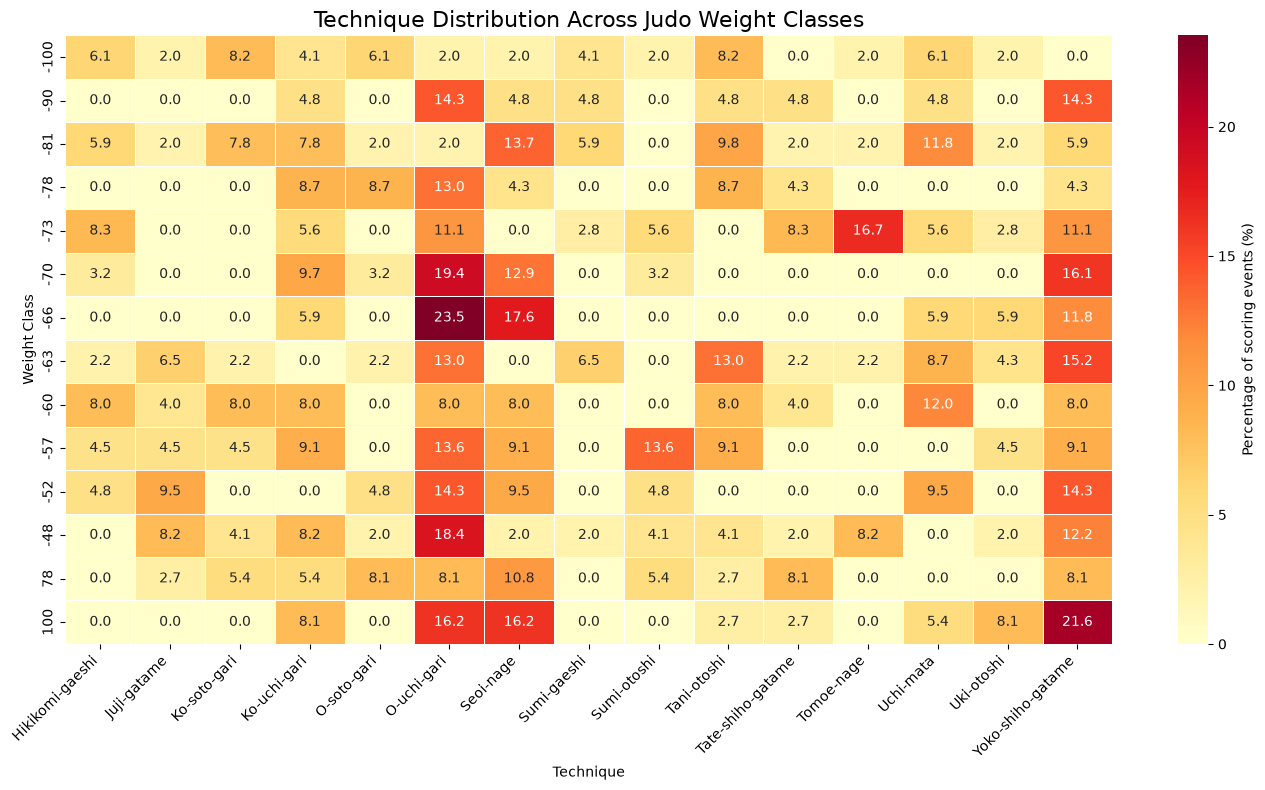

In [ ]:

weight_technique = (
    technique_df
    .groupby(["weight", "technique"])
    .size()
    .reset_index(name="count")
)


weight_totals = (
    weight_technique
    .groupby("weight")["count"]
    .transform("sum")
)

weight_technique["percentage"] = (
    weight_technique["count"] / weight_totals * 100
)


top_techniques = (
    technique_df["technique"]
    .value_counts()
    .head(15)
    .index
)


heatmap_data = (
    weight_technique[
        weight_technique["technique"]
        .isin(top_techniques)
    ]
    .pivot(
        index="weight",
        columns="technique",
        values="percentage"
    )
    .fillna(0)
)

plt.figure(figsize=(14, 8))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={
        "label": "Percentage of scoring events (%)"
    }
)


plt.title(
    "Technique Distribution Across Judo Weight Classes",
    fontsize=16
)

plt.xlabel(
    "Technique"
)

plt.ylabel(
    "Weight Class"
)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.tight_layout()

plt.show()

## Technique Distribution by Weight Class

This heatmap compares scoring technique preferences across international judo weight categories. Values represent the percentage contribution of each technique within a weight class, allowing comparison between divisions with different numbers of matches.

The analysis explores whether different weight categories demonstrate distinct technical profiles.

In [40]:
technique_df.to_csv(
    "../data/processed/clean_techniques.csv",
    index=False
)